# Lab02 - Regresión lineal simple con scikit-learn

## Objetivo

En este laboratorio voy a entrenar un modelo de regresión lineal simple usando `scikit-learn`.

La idea es usar el mismo dataset del Lab01 y comparar los parámetros aprendidos por la librería con los obtenidos manualmente mediante la función de coste y descenso de gradiente.

En el Lab01 implementé el proceso desde cero. En este laboratorio voy a usar una herramienta estándar de machine learning para ver cómo se hace en la práctica.

## Etapa 1 - Importar librerías

Para este laboratorio voy a usar:

- `numpy`, para trabajar con arrays;
- `matplotlib`, para graficar;
- `LinearRegression`, que es la clase de `scikit-learn` que permite entrenar una regresión lineal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

 ### Comentario sobre `LinearRegression`

`LinearRegression` es una clase de `scikit-learn` que permite crear un modelo de regresión lineal.

Al importarla todavía no se entrena ningún modelo. Solo se deja disponible la herramienta que después voy a usar para crear y entrenar el modelo.

El entrenamiento ocurre más adelante, cuando se ejecuta el método `.fit(X, y)`.

## Etapa 2 - Definir el dataset

Voy a usar el mismo dataset simple del Lab01.

El objetivo es mantener los mismos datos para poder comparar el resultado obtenido manualmente con el resultado obtenido usando `scikit-learn`.

El dataset representa una relación ficticia entre horas de estudio y puntaje obtenido en una prueba.

En este laboratorio:

- `x_train` representa la variable de entrada, es decir, las horas de estudio.
- `y_train` representa la variable objetivo, es decir, el puntaje obtenido.

Conceptualmente, el modelo va a aprender a partir de pares de datos:

- 1 hora de estudio → 52 puntos
- 2 horas de estudio → 57 puntos
- 3 horas de estudio → 63 puntos
- 4 horas de estudio → 68 puntos
- 5 horas de estudio → 74 puntos

En aprendizaje supervisado, `x_train` contiene los datos de entrada y `y_train` contiene los valores reales que el modelo debería aprender a predecir.

In [2]:
#Crea un array de NumPy con los valores de entrada.
#En este laboratorio, x_train representa las horas de estudio.
x_train = np.array([1, 2, 3, 4, 5])
#En este caso, y_train representa el puntaje obtenido.
y_train = np.array([52, 57, 63, 68, 74])

### Inspección inicial del dataset

Antes de entrenar el modelo, conviene verificar qué datos quedaron cargados.

La función `print` permite mostrar el contenido de los arrays.

También calculo la cantidad de ejemplos usando `len(x_train)`.

Como `x_train` y `y_train` tienen la misma cantidad de elementos, cada posición de ambos arrays forma un par de entrenamiento.

In [3]:
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")
print(f"Cantidad de ejemplos: {len(x_train)}")

x_train = [1 2 3 4 5]
y_train = [52 57 63 68 74]
Cantidad de ejemplos: 5


## Etapa 3 - Adaptar la forma de los datos para scikit-learn

`scikit-learn` espera que las variables de entrada estén en una matriz de dos dimensiones.

Aunque en este laboratorio tenemos una sola variable de entrada, horas de estudio, `scikit-learn` igualmente espera una estructura con forma de tabla.

Por eso, el array `x_train`, que originalmente tiene esta forma:

`[1, 2, 3, 4, 5]`

se convierte en una matriz con una columna:

`[[1], [2], [3], [4], [5]]`

Esto se hace con `reshape(-1, 1)`.

El `-1` le indica a NumPy que calcule automáticamente la cantidad de filas necesarias.

El `1` indica que queremos una sola columna.

Esta transformación no cambia los datos. Solo cambia su forma para que puedan ser usados por `scikit-learn`.

In [4]:
X = x_train.reshape(-1, 1)

print(f"x_train original:")
print(x_train)

print(f"X transformado:")
print(X)

x_train original:
[1 2 3 4 5]
X transformado:
[[1]
 [2]
 [3]
 [4]
 [5]]


## Etapa 4 - Crear el modelo de regresión lineal

Ahora voy a crear un modelo de regresión lineal usando `scikit-learn`.

Para eso uso la clase `LinearRegression`, que importé al comienzo del laboratorio con:

`from sklearn.linear_model import LinearRegression`

La sentencia:

`modelo = LinearRegression()`

crea un objeto modelo de regresión lineal.

En este punto el modelo todavía no aprendió nada.  
Solo estoy creando la estructura del modelo.

El entrenamiento ocurre recién cuando se ejecuta el método `.fit(X, y_train)`.

In [5]:
modelo = LinearRegression()

### Verificación del objeto modelo

Puedo imprimir el objeto `modelo` para verificar que fue creado correctamente.

Esto no muestra todavía parámetros aprendidos, porque el modelo aún no fue entrenado.

In [6]:
print(modelo)

LinearRegression()


## Etapa 5 - Entrenar el modelo con `.fit()`

Ahora voy a entrenar el modelo usando el método `.fit()`.

La sentencia:

`modelo.fit(X, y_train)`

le indica a `scikit-learn` que debe ajustar el modelo de regresión lineal usando los datos de entrenamiento.

En esta etapa, el modelo recibe:

- `X`: matriz con las variables de entrada;
- `y_train`: valores reales que el modelo debe aprender a predecir.

En nuestro caso:

- `X` contiene las horas de estudio;
- `y_train` contiene los puntajes reales.

Conceptualmente, `.fit()` busca los valores de los parámetros `w` y `b` que hacen que la recta se ajuste lo mejor posible a los datos.

En el Lab01 calculamos esos parámetros manualmente con descenso de gradiente.

En este laboratorio, `scikit-learn` hace ese ajuste automáticamente.


In [7]:
modelo.fit(X, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Salida de `modelo.fit(X, y_train)`

Al ejecutar:

`modelo.fit(X, y_train)`

`scikit-learn` entrena el modelo de regresión lineal usando los datos de entrada `X` y los valores reales `y_train`.

La salida que muestra Jupyter no es una predicción ni el resultado final del modelo.  
Es la representación del objeto `LinearRegression` después de haber sido ajustado.

Esto ocurre porque `.fit()` devuelve el propio objeto modelo entrenado.

Por eso Jupyter muestra una tarjeta con el nombre del modelo y algunos parámetros de configuración.

Los parámetros que aparecen ahí no son todavía `w` y `b`.  
Son opciones internas de configuración del modelo.

Los valores realmente aprendidos por el modelo se consultan después con:

- `modelo.coef_`, para obtener la pendiente `w`;
- `modelo.intercept_`, para obtener la ordenada al origen `b`.

## Etapa 6 - Realizar predicciones con el modelo entrenado

Una vez que el modelo fue entrenado con `.fit(X, y_train)`, ya puede usarse para realizar predicciones.

Para eso se usa el método `.predict()`.

La sentencia:

`modelo.predict(X)`

le pide al modelo que prediga valores de `y` para los datos de entrada `X`.

En este caso, voy a predecir los puntajes para las mismas horas de estudio usadas en el entrenamiento.

Esto permite comparar:

- los valores reales `y_train`;
- los valores estimados por el modelo `y_pred`.

En regresión lineal simple, estas predicciones corresponden a aplicar la recta aprendida:

$f_{w,b}(x) = wx + b$

In [8]:
y_pred = modelo.predict(X)

print(f"Valores reales:     {y_train}")
print(f"Valores estimados:  {y_pred}")

Valores reales:     [52 57 63 68 74]
Valores estimados:  [51.8 57.3 62.8 68.3 73.8]


### Explicación de `modelo.predict(X)`

La sentencia:

`y_pred = modelo.predict(X)`

usa el modelo entrenado para calcular predicciones.

`X` contiene los datos de entrada.

`modelo.predict(X)` devuelve un array con una predicción para cada fila de `X`.

Como `X` tiene cinco ejemplos, `y_pred` tendrá cinco valores estimados.

Estas predicciones no son los datos reales.  
Son los valores que el modelo estima usando los parámetros `w` y `b` aprendidos durante el entrenamiento.

In [9]:
for i in range(len(x_train)):
    print(f"Horas={x_train[i]} | Real={y_train[i]} | Estimado={y_pred[i]}")

Horas=1 | Real=52 | Estimado=51.79999999999999
Horas=2 | Real=57 | Estimado=57.3
Horas=3 | Real=63 | Estimado=62.8
Horas=4 | Real=68 | Estimado=68.3
Horas=5 | Real=74 | Estimado=73.8


## Etapa 7 - Graficar los valores reales y la recta estimada

Ahora voy a graficar los datos reales junto con la recta estimada por el modelo.

Los puntos representan los datos originales del dataset.

La recta representa los valores estimados por el modelo de regresión lineal.

Esto permite ver visualmente qué tan bien se ajusta el modelo a los datos.

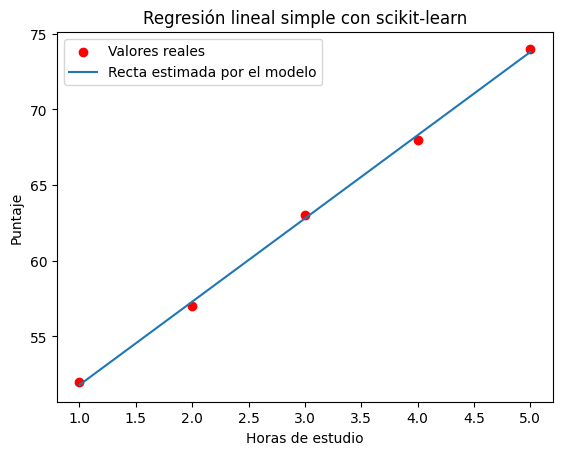

In [10]:
plt.scatter(x_train, y_train, c='r', label="Valores reales")
plt.plot(x_train, y_pred, label="Recta estimada por el modelo")

plt.xlabel("Horas de estudio")
plt.ylabel("Puntaje")
plt.title("Regresión lineal simple con scikit-learn")

plt.legend()
plt.show()

### Explicación del gráfico

La sentencia `plt.scatter(x_train, y_train)` dibuja los datos reales como puntos.

En este gráfico:

- el eje `x` representa las horas de estudio;
- el eje `y` representa el puntaje obtenido.

La sentencia `plt.plot(x_train, y_pred)` dibuja la recta estimada por el modelo.

`y_pred` contiene los valores estimados por el modelo para cada valor de `x_train`.

Si la recta pasa cerca de los puntos reales, significa que el modelo está ajustando razonablemente bien los datos.

La sentencia `plt.legend()` muestra la leyenda del gráfico.

La sentencia `plt.show()` muestra el gráfico final.

## Etapa 8 - Comparar con el resultado del Lab01

En el Lab01 implementé la regresión lineal simple desde cero y obtuve valores aproximados para los parámetros `w` y `b`.

En este laboratorio, `scikit-learn` calculó automáticamente esos parámetros usando `LinearRegression`.

La comparación permite verificar que ambos enfoques llegan prácticamente al mismo modelo.

Esto muestra que la implementación manual del Lab01 y la implementación profesional de `scikit-learn` están resolviendo el mismo problema matemático: encontrar la recta que mejor ajusta los datos.

In [11]:
w_lab01 = 5.5015501898171495
b_lab01 = 46.294403322887526
w = modelo.coef_[0]
b = modelo.intercept_

print(f"w Lab01 manual:       {w_lab01}")
print(f"w scikit-learn:       {w}")

print(f"b Lab01 manual:       {b_lab01}")
print(f"b scikit-learn:       {b}")

w Lab01 manual:       5.5015501898171495
w scikit-learn:       5.500000000000002
b Lab01 manual:       46.294403322887526
b scikit-learn:       46.29999999999999


## Etapa 9 - Estimar un valor nuevo

Una vez entrenado el modelo, puedo usarlo para estimar el puntaje correspondiente a un valor de entrada nuevo.

Por ejemplo, voy a estimar qué puntaje correspondería a `6` horas de estudio.

Para usar `.predict()` en `scikit-learn`, el valor nuevo también debe respetar el formato de matriz de dos dimensiones.

Por eso escribo:

`[[6]]`

y no simplemente:

`6`

El doble corchete representa una matriz con una fila y una columna.

In [12]:
nuevo_x = np.array([[6]])

estimacion = modelo.predict(nuevo_x)

print(f"Para 6 horas de estudio, el puntaje estimado es: {estimacion[0]}")

Para 6 horas de estudio, el puntaje estimado es: 79.30000000000001


## Etapa 10 - Comparar el desempeño de los modelos

La idea es comparar los valores reales `y_train` contra los valores estimados por cada modelo.

Una forma común de medir el error es calcular el error cuadrático medio.

Para cada ejemplo se calcula:

$(y_{estimado} - y_{real})^2$

Luego se promedian esos errores.

Cuanto menor sea la función de coste (error cuadrático medio), mejor ajusta el modelo a estos datos de entrenamiento.

En este laboratorio voy a comparar:

- el modelo obtenido manualmente en el Lab01;
- el modelo entrenado con `scikit-learn`.

In [13]:
# Valores obtenidos en el Lab01 con descenso de gradiente
w_lab01 = 5.5015501898171495
b_lab01 = 46.294403322887526

# Estimaciones del modelo manual
y_estimado_lab01 = w_lab01 * x_train + b_lab01

# Estimaciones del modelo scikit-learn
y_estimado_sklearn = modelo.predict(X)

# Cálculo del error cuadrático medio
mse_lab01 = np.mean((y_estimado_lab01 - y_train) ** 2)
mse_sklearn = np.mean((y_estimado_sklearn - y_train) ** 2)

print(f"Error cuadrático medio Lab01:        {mse_lab01}")
print(f"Error cuadrático medio scikit-learn: {mse_sklearn}")

Error cuadrático medio Lab01:        0.060005701296644065
Error cuadrático medio scikit-learn: 0.060000000000000574


In [14]:
coste_lab01 = mse_lab01 / 2
coste_sklearn = mse_sklearn / 2

print(f"Coste Lab01:        {coste_lab01}")
print(f"Coste scikit-learn: {coste_sklearn}")

Coste Lab01:        0.030002850648322033
Coste scikit-learn: 0.030000000000000287


En este ejemplo, `scikit-learn` obtiene un coste levemente menor porque calcula directamente los parámetros que minimizan el error cuadrático.

La implementación manual del Lab01 se aproxima a esa solución mediante descenso de gradiente, por lo que el resultado depende de factores como la tasa de aprendizaje, la cantidad de iteraciones y el criterio de corte.

## Conclusión

En este laboratorio entrené una regresión lineal simple usando `scikit-learn`.

Al comparar los parámetros y el coste con la implementación manual del Lab01, se observa que ambos enfoques llegan a resultados muy similares.

La diferencia principal es que `scikit-learn` automatiza el proceso de entrenamiento, mientras que en el Lab01 se implementaron manualmente la función de coste y el descenso de gradiente.